In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
lr = 0.0001
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size= 64
epochs = 200
latent_dim = 100
plot_loss_freq=40
plot_generation_freq=40
num_gens = 10
label_smoothing = 0.05

In [3]:
class Discriminator(nn.Module):
  def __init__(self, dropout=0.2):
    super().__init__()
    self.discriminator = nn.Sequential(
        nn.Linear(28*28, 1024),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(1024, 512),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, 256),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 1), #this is 1 so that the discriminator outputs jjust one output either real or fake
    )

  def forward(self, x):
    batch_size = x.shape[0]
    x = x.reshape(batch_size, -1)
    x = self.discriminator(x)
    return x

In [4]:
disc = Discriminator()

#batch_size, channels, height, width

rand = torch.randn(4, 1, 28, 28)
disc(rand)

tensor([[-0.0205],
        [-0.0106],
        [ 0.0020],
        [ 0.0651]], grad_fn=<AddmmBackward0>)

In [5]:
class Generator(nn.Module):
  def __init__(self, latent_dim, dropout=0.2):
    super().__init__()
    self.generator = nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 512),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(512, 1024),
        nn.LeakyReLU(),
        nn.Dropout(dropout),
        nn.Linear(1024, 28*28),
        nn.Tanh()
    )

  def forward(self, x):
    batch_size = x.shape[0]
    x = self.generator(x)
    x = x.reshape(batch_size, 1, 28, 28)
    return x


In [6]:
discriminator = Discriminator().to(device)
generator = Generator(latent_dim=latent_dim).to(device)

In [7]:
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)
g_optimizer = optim.Adam(generator.parameters(), lr)

In [8]:
criterion = nn.BCEWithLogitsLoss()

In [9]:
#dataset
from torchvision.transforms import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_dataset = MNIST("./data", transform=transform, download=True)

In [10]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch1 Generator loss:  2.6781 | Discriminator Loss:  0.3127


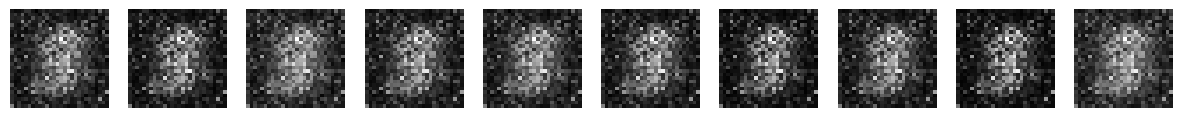

 20%|██        | 40/200 [04:53<19:35,  7.35s/it]

Epoch41 Generator loss:  1.6891 | Discriminator Loss:  0.3966


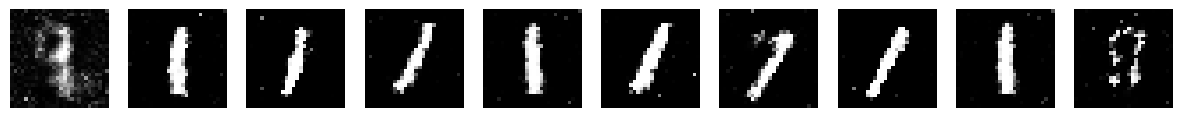

 40%|████      | 80/200 [09:49<14:44,  7.37s/it]

Epoch81 Generator loss:  1.4084 | Discriminator Loss:  0.4671


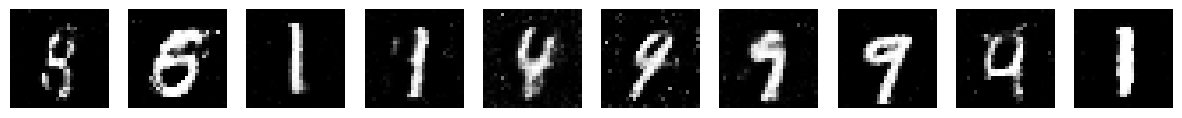

 60%|██████    | 120/200 [14:43<09:51,  7.39s/it]

Epoch121 Generator loss:  1.3577 | Discriminator Loss:  0.4811


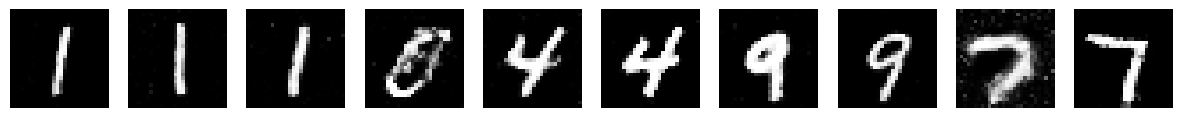

 80%|████████  | 160/200 [19:46<05:02,  7.57s/it]

Epoch161 Generator loss:  1.3655 | Discriminator Loss:  0.4846


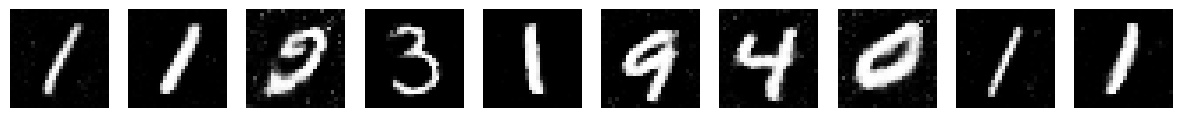

100%|██████████| 200/200 [24:44<00:00,  7.42s/it]


In [11]:
#training_loop
import numpy as np
from tqdm import tqdm

gen_loss, disc_loss = [], []
for epoch in tqdm(range(epochs)):
  gen_epoch_loss=[]
  disc_epoch_loss=[]
  for images, _ in train_dataloader:
    batch_size = images.shape[0]
    images = images.to(device)
    noise = torch.randn(batch_size, latent_dim, device=device)

    generated_labels = torch.zeros(batch_size, 1, device=device) + label_smoothing
    true_labels = torch.ones(batch_size, 1, device=device) - label_smoothing

    generated_images = generator(noise).detach()
    real_discriminator_pred = discriminator(images)
    gen_discriminator_pred = discriminator(generated_images)

    real_loss = criterion(real_discriminator_pred, true_labels)
    fake_loss = criterion(gen_discriminator_pred, generated_labels)
    discriminator_loss = (real_loss + fake_loss) / 2
    disc_epoch_loss.append(discriminator_loss.item())

    d_optimizer.zero_grad()
    discriminator_loss.backward()
    d_optimizer.step()

    noise = torch.randn(batch_size, latent_dim ,device=device)
    generated_images = generator(noise)
    gen_discriminator_pred = discriminator(generated_images)
    generator_loss = criterion(gen_discriminator_pred, true_labels)
    gen_epoch_loss.append(generator_loss.item())

    g_optimizer.zero_grad()
    generator_loss.backward()
    g_optimizer.step()


  disc_epoch_loss = np.mean(disc_epoch_loss)
  gen_epoch_loss = np.mean(gen_epoch_loss)

  if epoch % plot_loss_freq == 0:
    print(f"Epoch{epoch+1} Generator loss: {gen_epoch_loss : .4f} | Discriminator Loss: {disc_epoch_loss : .4f}")

  gen_loss.append(gen_epoch_loss)
  disc_loss.append(disc_epoch_loss)

  if epoch % plot_generation_freq == 0:
    generator.eval()
    with torch.no_grad():
      noise_sample = torch.randn(num_gens, latent_dim, device=device)
      generated_images = generator(noise_sample).to("cpu")

      fig, ax = plt.subplots(1, num_gens, figsize=(15,5))

      for i in range(num_gens):
        img = (generated_images[i].squeeze() + 1 ) /2
        ax[i].imshow(img.numpy(), cmap="gray")
        ax[i].set_axis_off()

      plt.show()

    generator.train()





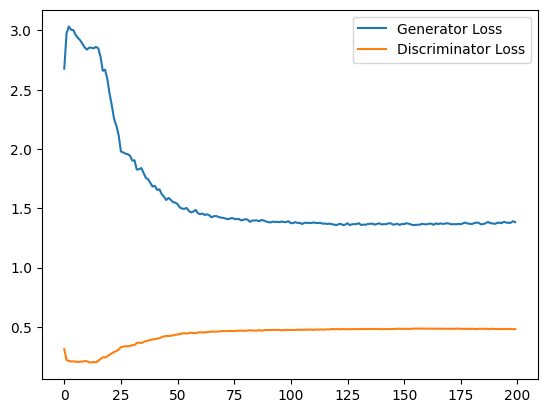

In [13]:
plt.plot(gen_loss, label="Generator Loss")
plt.plot(disc_loss, label="Discriminator Loss")
plt.legend()
plt.show()

In [14]:
torch.save({
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'g_optimizer_state_dict': g_optimizer.state_dict(),
    'd_optimizer_state_dict': d_optimizer.state_dict(),
    'epoch': epoch,
    'gen_loss': gen_loss,
    'disc_loss': disc_loss
}, "gan_full_checkpoint.pth")

In [15]:
torch.save(generator.state_dict(), "generator.pth")

In [16]:
from huggingface_hub import login

login()

In [18]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "maharjanabeeral/unconditional-mnist-gan"

api.create_repo(repo_id=repo_id, exist_ok=True)

api.upload_file(
    path_or_fileobj="gan_full_checkpoint.pth",
    path_in_repo="gan_full_checkpoint.pth",
    repo_id=repo_id
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  gan_full_checkpoint.pth     :  16%|#5        | 5.65MB / 35.4MB            

CommitInfo(commit_url='https://huggingface.co/maharjanabeeral/unconditional-mnist-gan/commit/752df5f01dc6a782e4a012a15c6f2e0ebc835f56', commit_message='Upload gan_full_checkpoint.pth with huggingface_hub', commit_description='', oid='752df5f01dc6a782e4a012a15c6f2e0ebc835f56', pr_url=None, repo_url=RepoUrl('https://huggingface.co/maharjanabeeral/unconditional-mnist-gan', endpoint='https://huggingface.co', repo_type='model', repo_id='maharjanabeeral/unconditional-mnist-gan'), pr_revision=None, pr_num=None)